In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix

In [ ]:
data = pd.read_csv('german_credit_data.csv')

In [ ]:
data.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [ ]:
data.shape

(1000, 11)

In [ ]:
data = data.set_index(data.columns[0])
data.index = data.index + 1

In [ ]:
data.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
Unnamed: 0,,,,,,,,,,
1,67,male,2,own,NaN,little,1169,6,radio/TV,good
2,22,female,2,own,little,moderate,5951,48,radio/TV,bad
3,49,male,1,own,little,NaN,2096,12,education,good
4,45,male,2,free,little,little,7882,42,furniture/equipment,good
5,53,male,2,free,little,little,4870,24,car,bad


**EDA**

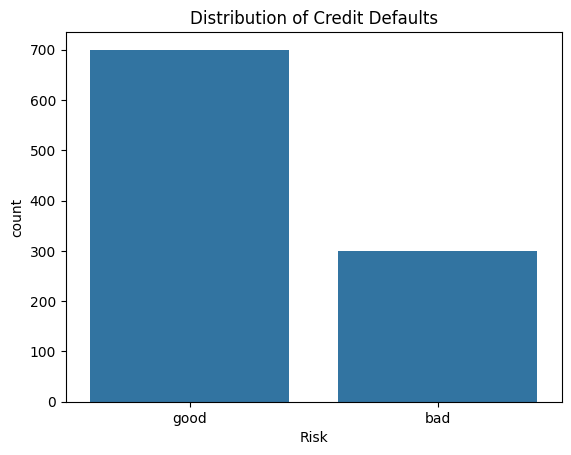

In [ ]:
#checking for the imbalance in data
sns.countplot(x='Risk', data=data)
plt.title('Distribution of Credit Defaults')
plt.show()

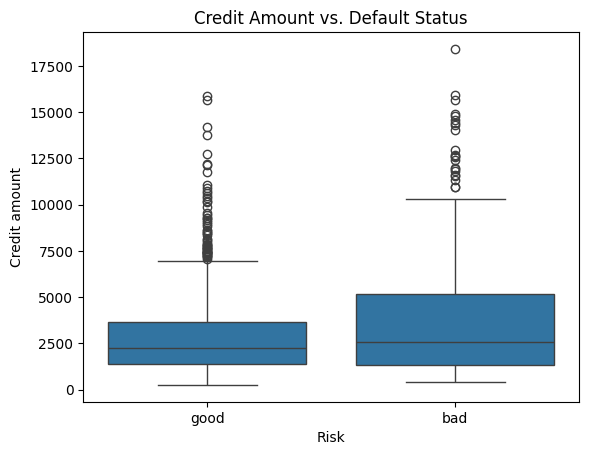

In [ ]:
#relation between loan amount and the default
sns.boxplot(x='Risk', y='Credit amount', data=data)
plt.title('Credit Amount vs. Default Status')
plt.show()

In [ ]:
print(data.isnull().sum())

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64


Text(0.5, 1.0, 'Credit Amount and Saving accounts: Missing Data vs. Observed Data')

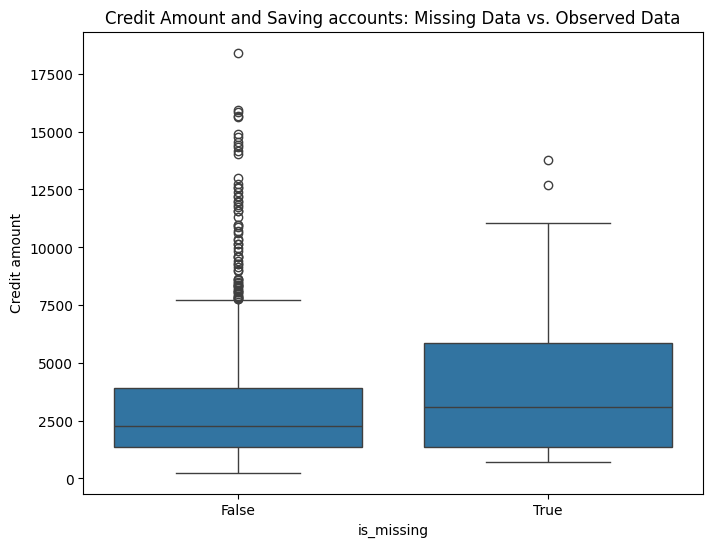

In [ ]:
#We are going to check whether the people who dont have Saving and Checking account are poor daily wage worker according to the credit amount
data['is_missing'] = data['Saving accounts'].isnull() & data['Checking account'].isnull()
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_missing', y='Credit amount', data=data)
plt.title('Credit Amount and Saving accounts: Missing Data vs. Observed Data')

In [ ]:
# looking at the graphs, we decided to convert all the missing values into 'little', following the hypothesis that they are the people who are poor and the source of income is mostly daily wage and yransactions in form of cash
status_cols = ['Checking account', 'Saving accounts']
for col in status_cols:
    data[col] = data[col].fillna('little')
status_mapping = {'little': 1, 'moderate': 2, 'rich': 3, 'quite rich': 4}
for col in status_cols:
    data[col] = data[col].map(status_mapping)
data['Checking account'] = pd.to_numeric(data['Checking account'])
data['Saving accounts'] = pd.to_numeric(data['Saving accounts'])

In [ ]:
data = data.drop('is_missing', axis=1)

In [ ]:
data.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
Unnamed: 0,,,,,,,,,,
1,67,male,2,own,1,1,1169,6,radio/TV,good
2,22,female,2,own,1,2,5951,48,radio/TV,bad
3,49,male,1,own,1,1,2096,12,education,good
4,45,male,2,free,1,1,7882,42,furniture/equipment,good
5,53,male,2,free,1,1,4870,24,car,bad


In [ ]:
data['target'] = data['Risk'].map({'good': 1, 'bad': 0})
data = data.drop('Risk', axis=1)
nominal_cols = ['Sex', 'Purpose', 'Housing', 'Job']
data = pd.get_dummies(data, columns=nominal_cols, drop_first=True)
bool_cols = data.select_dtypes(include=['bool']).columns
data[bool_cols] = data[bool_cols].astype(int)



In [ ]:
data.head()

,Age,Saving accounts,Checking account,Credit amount,Duration,target,Sex_male,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Housing_own,Housing_rent,Job_1,Job_2,Job_3
Unnamed: 0,,,,,,,,,,,,,,,,,,,
1,67,1,1,1169,6,1,1,0,0,0,0,1,0,0,1,0,0,1,0
2,22,1,2,5951,48,0,0,0,0,0,0,1,0,0,1,0,0,1,0
3,49,1,1,2096,12,1,1,0,0,1,0,0,0,0,1,0,1,0,0
4,45,1,1,7882,42,1,1,0,0,0,1,0,0,0,0,0,0,1,0
5,53,1,1,4870,24,0,1,1,0,0,0,0,0,0,0,0,0,1,0


In [ ]:
#In a credit default model, the large values like high credit amount or high duration plays a important role in training for default, hence we will not be removing these.

In [ ]:
X = data.drop('target', axis=1)
y = data['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Pre-processing for imbalanced data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [ ]:
models_and_params = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, class_weight='balanced'),
        {"C": [0.1, 1, 10]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {"n_estimators": [50, 100], "max_depth": [5, 10]}
    ),
    "XGBoost": (
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        {"n_estimators": [50, 100], "learning_rate": [0.01, 0.1]}
    )
}
results = {}
best_estimators = {}

In [ ]:
for name, (model, params) in models_and_params.items():
    print(f"Tuning {name}...")
    grid = GridSearchCV(model, params, scoring='roc_auc', cv=3, n_jobs=-1)
    grid.fit(X_train_resampled, y_train_resampled)

    # Predict using scaled test data
    probs = grid.best_estimator_.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, probs)

    results[name] = auc
    best_estimators[name] = grid.best_estimator_
    print(f"{name} Best AUC: {auc:.3f}")

Tuning Logistic Regression...
Logistic Regression Best AUC: 0.588
Tuning Random Forest...
Random Forest Best AUC: 0.653
Tuning XGBoost...
XGBoost Best AUC: 0.670


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:52:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
best_model_name = max(results, key=results.get)
final_model = best_estimators[best_model_name]
print(f"best algo: {best_model_name}")

best algo: XGBoost


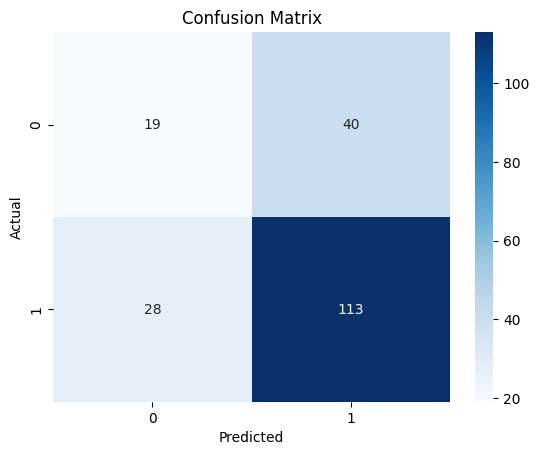

In [ ]:
y_pred = final_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
risk_data = pd.DataFrame(X_test, columns=X.columns)
risk_data['Prob_of_Default'] = 1 - final_model.predict_proba(X_test_scaled)[:, 1]
risk_data['Expected_Loss'] = risk_data['Prob_of_Default'] * risk_data['Credit amount'] * 0.80
columns_to_show = [
    'Prob_of_Default',
    'Expected_Loss',
    'Credit amount',
    'Duration',
    'Age'
]
print(risk_data[columns_to_show].sort_values(by='Expected_Loss', ascending=False).head(10))

            Prob_of_Default  Expected_Loss  Credit amount  Duration  Age
Unnamed: 0                                                              
64                 0.895159   10327.270422          14421        48   25
715                0.568221    6376.346464          14027        60   27
523                0.945902    5387.100334           7119        48   53
550                0.740139    5244.918529           8858        48   35
651                0.857134    5126.348004           7476        48   50
830                0.849159    4538.584398           6681        48   38
903                0.519961    4358.109110          10477        36   42
45                 0.854531    4199.509148           6143        48   58
71                 0.604349    3932.137996           8133        36   30
918                0.298587    3558.206822          14896         6   68
